In [1]:
# --- Standard Library Imports ---
import os
import shutil
import csv
import random
import time
from pathlib import Path

# --- Third-Party Data & Math Imports ---
import numpy as np
import pandas as pd
import yaml

# --- Third-Party Image & Visualization Imports ---
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm import tqdm

# --- Machine Learning & Deep Learning Imports ---
import torch
from ultralytics import YOLO
from sklearn.metrics import precision_score, recall_score, f1_score


# Device configuration (GPU if available)
def select_device():
    if torch.cuda.is_available(): return "cuda"
    if hasattr(torch, "xpu") and torch.xpu.is_available(): return "xpu"
    return "cpu"

device = select_device()
print(f"Using device: {device}")

# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"Project Root: {PROJECT_ROOT}")

# Model name used in training 
MODEL_NAME = "yolov8n_vehicle_detection"

Using device: cuda
Project Root: c:\Users\alera\Desktop\ENTPE\ICVIS\project\ICV_project


## Load the best model

In [2]:
# Define path to runs directory
runs_path = Path(PROJECT_ROOT) / 'results'

# Path to "best.pt" model
best_model_path = runs_path / MODEL_NAME / 'weights' / 'best.pt'

# Check if best.pt exists
if best_model_path.exists():
    # Load best YOLO model
    best_model = YOLO(str(best_model_path))
    print(f" Best model loaded from: {best_model_path}")
    
    # Display total model parameters
    print(f"Model parameters: {sum(p.numel() for p in best_model.model.parameters()) / 1e6:.2f}M")
    
    # Path to training results file (CSV) for info
    results_path = runs_path / MODEL_NAME / 'results.csv'
    
    if results_path.exists():
        results_df = pd.read_csv(results_path)
        best_epoch = results_df['metrics/mAP50(B)'].idxmax()
        best_map = results_df['metrics/mAP50(B)'].max()
        print(f"\n Best Training Results:")
        print(f"  Best Epoch: {best_epoch + 1}")
        print(f"  Best mAP50: {best_map:.4f}")
else:
    print(f" Best model not found at {best_model_path}")
    best_model = None

 Best model loaded from: c:\Users\alera\Desktop\ENTPE\ICVIS\project\ICV_project\results\yolov8n_vehicle_detection\weights\best.pt
Model parameters: 3.01M

 Best Training Results:
  Best Epoch: 32
  Best mAP50: 0.7941


## IoU calculation and visualization

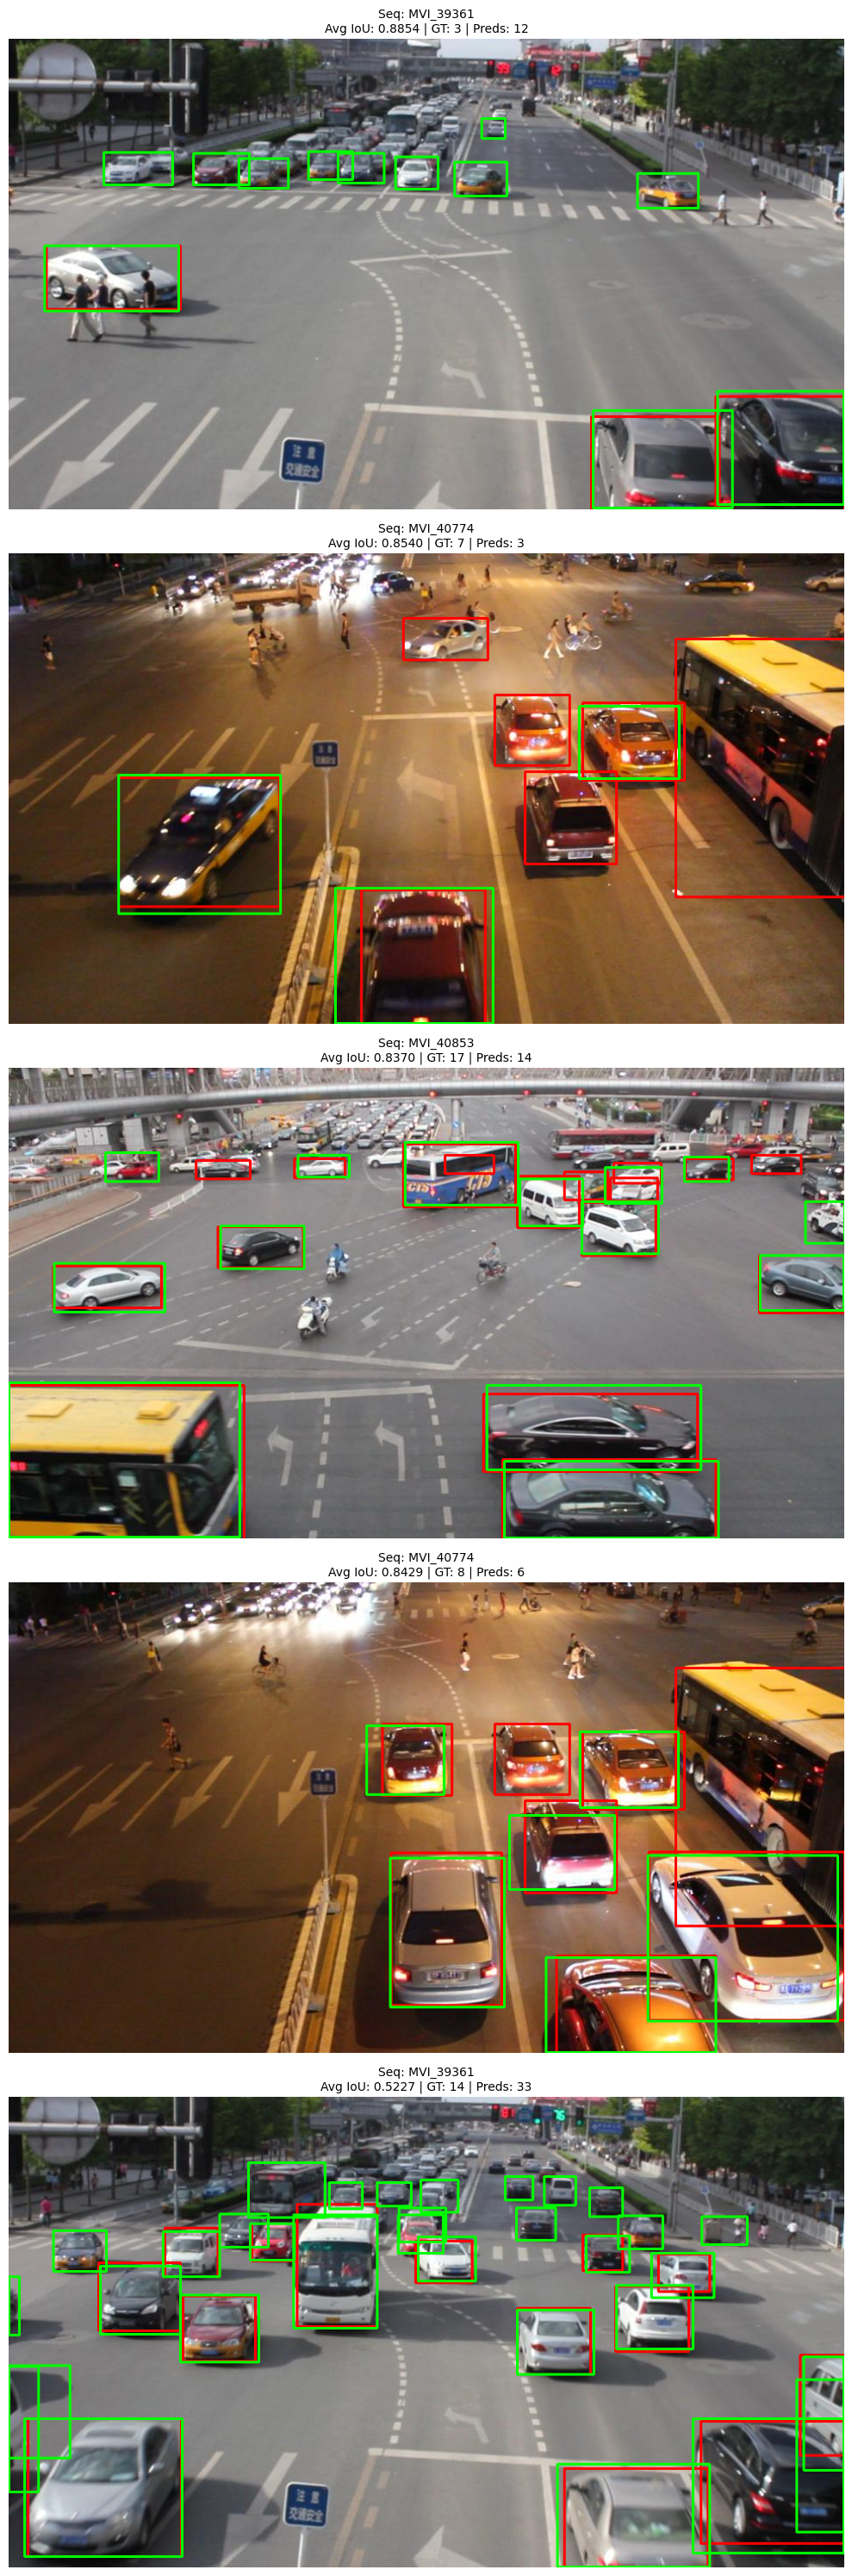

In [3]:
# helper function to calculate IoU  
def calculate_iou(box1, box2):
    # box: [x_center, y_center, width, height]
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # corner coordinates (x_min, y_min, x_max, y_max)
    b1_x1, b1_x2 = x1 - w1/2, x1 + w1/2
    b1_y1, b1_y2 = y1 - h1/2, y1 + h1/2
    b2_x1, b2_x2 = x2 - w2/2, x2 + w2/2
    b2_y1, b2_y2 = y2 - h2/2, y2 + h2/2

    # Intersection
    inter_x1 = max(b1_x1, b2_x1)
    inter_y1 = max(b1_y1, b2_y1)
    inter_x2 = min(b1_x2, b2_x2)
    inter_y2 = min(b1_y2, b2_y2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    
    # Individual areas
    b1_area = w1 * h1
    b2_area = w2 * h2
    
    # Union
    union_area = b1_area + b2_area - inter_area
    
    if union_area == 0: return 0
    return inter_area / union_area

def visualize_predictions(num_samples=3):
    test_results_path = Path(PROJECT_ROOT) / 'results' / 'test_results' / MODEL_NAME
    test_images_base = Path(PROJECT_ROOT) / "data_processed/test/images"
    gt_labels_base = Path(PROJECT_ROOT) / "data_processed/test/labels"
    
    sequences = sorted([d for d in test_images_base.iterdir() if d.is_dir()])
    if not sequences: return
    
    # layout for subplots
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, 6 * num_samples))
    if num_samples == 1: axes = [axes]
    
    count = 0
    # we loop until we collect num_samples valid images
    while count < num_samples:
        # randomly select a sequence
        seq_folder = random.choice(sequences)
        pred_labels_dir = test_results_path / seq_folder.name / "labels"
        
        if not pred_labels_dir.exists(): continue
        
        pred_files = list(pred_labels_dir.glob('*.txt'))
        if not pred_files: continue
        
        # randomly select a file
        pred_file = random.choice(pred_files)
        img_name = pred_file.stem + ".jpg"
        img_path = seq_folder / img_name
        
        if not img_path.exists(): 
            img_path = seq_folder / (pred_file.stem + ".png")
            
        if img_path.exists():
            img = cv2.imread(str(img_path))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            
            # --- 1. data LOADING ---
            gt_boxes = []   
            pred_boxes = [] 

            # Read GT
            gt_file = gt_labels_base / seq_folder.name / pred_file.name
            if gt_file.exists():
                with open(gt_file, 'r') as f:
                    for line in f:
                        parts = list(map(float, line.split()))
                        if len(parts) >= 5:
                            gt_boxes.append(parts[1:5]) # Save normalized x,y,w,h

            # Read Predictions
            with open(pred_file, 'r') as f:
                for line in f:
                    parts = list(map(float, line.split()))
                    if len(parts) >= 5:
                        pred_boxes.append(parts[1:5]) # Save normalized x,y,w,h

            # --- 2. CALC AVG IOU FOR IMAGE ---
            img_iou_scores = []
            
            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                for p_box in pred_boxes:
                    # For each prediction, find the best fitting GT (Max IoU)
                    best_iou_for_box = 0
                    for g_box in gt_boxes:
                        iou = calculate_iou(p_box, g_box)
                        if iou > best_iou_for_box:
                            best_iou_for_box = iou
                    
                    # Consider only if there is a minimum overlap for the average
                    if best_iou_for_box > 0:
                        img_iou_scores.append(best_iou_for_box)
            
            avg_iou = np.mean(img_iou_scores) if img_iou_scores else 0.0

            # --- 3. draw ON IMAGE ---
            # Draw GT (Red)
            for box in gt_boxes:
                x, y, bw, bh = box
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            
            # Draw Predictions (Green)
            for box in pred_boxes:
                x, y, bw, bh = box
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # --- 4. visualization ---
            axes[count].imshow(img)
            axes[count].set_title(
                f"Seq: {seq_folder.name}\n"
                f"Avg IoU: {avg_iou:.4f} | GT: {len(gt_boxes)} | Preds: {len(pred_boxes)}",
                fontsize=10
            )
            axes[count].axis('off')
            
            count += 1

    plt.tight_layout()
    plt.show()

# Run visualization
visualize_predictions(5)

## Compute IoU for all the test set and plot graphs
30 mins requiered to run code below

[INFO] Starting combined analysis on 40 sequences...


Processing Sequences: 100%|██████████| 40/40 [37:13<00:00, 55.83s/seq]


[INFO] Analysis completed in 2233.14s

GLOBAL RESULTS
- Precision: 0.6795
- Recall:    0.6172
- F1-Score:  0.6468
- Mean IoU:  0.7816

Class      Precision  Recall     F1        
---------------------------------------------
car        0.6866     0.6411     0.6631    
bus        0.7210     0.5814     0.6437    
van        0.4671     0.3426     0.3953    


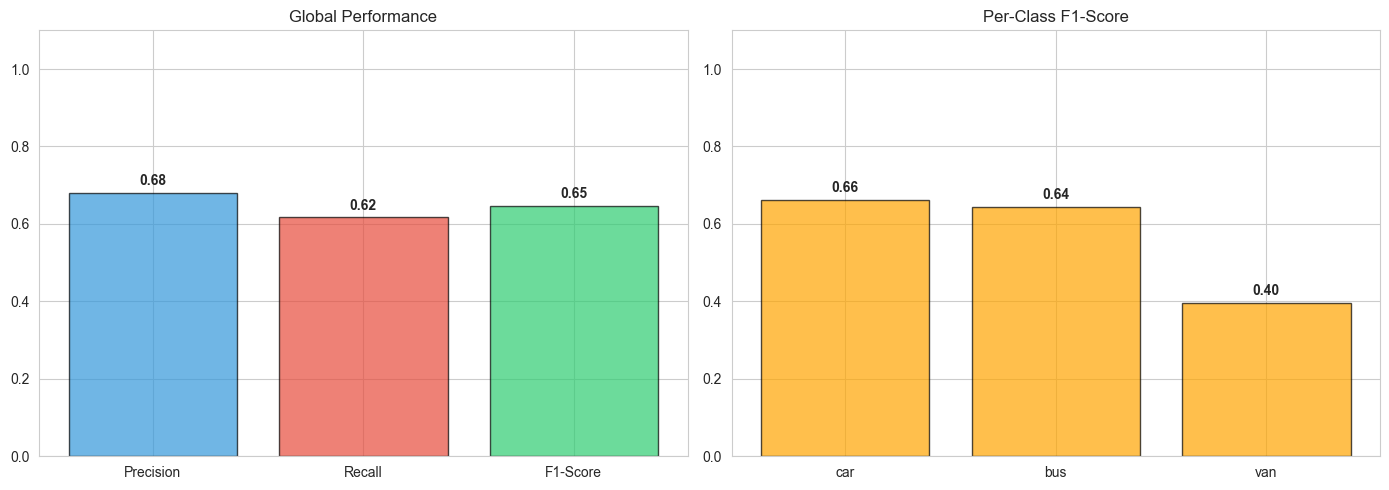


[INFO] All results saved to: c:\Users\alera\Desktop\ENTPE\ICVIS\project\ICV_project\results\metrics_analysis


In [4]:
# --- CONFIGURATION ---
BATCH_SIZE = 16
IMG_SIZE = 352
CONF_THRES = 0.25      # Threshold for detection confidence
IOU_THRES_NMS = 0.6    # Threshold for NMS during inference
IOU_THRES_MATCH = 0.5  # Threshold to consider a prediction a True Positive (Metric calculation)

CLASS_NAMES = {0: 'car', 1: 'bus', 2: 'van'}


# --- UTILS: GPU IOU FUNCTION ---
def compute_iou_batch(box1, box2):
    """
    Calculates IoU matrix between predictions and Ground Truth on GPU.
    Input format: normalized [x, y, w, h]
    """
    # Convert to Top-Left / Bottom-Right coordinates
    b1_x1, b1_x2 = box1[:, 0] - box1[:, 2] / 2, box1[:, 0] + box1[:, 2] / 2
    b1_y1, b1_y2 = box1[:, 1] - box1[:, 3] / 2, box1[:, 1] + box1[:, 3] / 2
    b2_x1, b2_x2 = box2[:, 0] - box2[:, 2] / 2, box2[:, 0] + box2[:, 2] / 2
    b2_y1, b2_y2 = box2[:, 1] - box2[:, 3] / 2, box2[:, 1] + box2[:, 3] / 2

    # Calculate intersection
    inter_x1 = torch.max(b1_x1[:, None], b2_x1)
    inter_y1 = torch.max(b1_y1[:, None], b2_y1)
    inter_x2 = torch.min(b1_x2[:, None], b2_x2)
    inter_y2 = torch.min(b1_y2[:, None], b2_y2)

    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    
    # Calculate Union
    area1 = box1[:, 2] * box1[:, 3]
    area2 = box2[:, 2] * box2[:, 3]
    union_area = area1[:, None] + area2 - inter_area
    
    return inter_area / (union_area + 1e-6)

# --- MAIN EVALUATION LOOP ---
# Ensure 'best_model' and 'device' are defined in your environment before running this block
if 'best_model' in locals() and best_model is not None:
    
    # 1. Setup Directories
    test_images_base =  Path(PROJECT_ROOT) / "data_processed/test/images"
    gt_labels_base = Path(PROJECT_ROOT) / "data_processed/test/labels"
    results_dir = Path(PROJECT_ROOT) / "results/metrics_analysis"
    results_dir.mkdir(parents=True, exist_ok=True)
    
    sequence_folders = sorted([d for d in test_images_base.iterdir() if d.is_dir()])
    
    # 2. Accumulators
    # For Distribution Analysis (Code 1)
    all_ious_dist = []     
    all_confs_dist = []
    
    # For Classification Metrics (Code 2)
    all_predictions_metric = []
    all_ground_truth_metric = []
    class_metrics = {name: [] for name in CLASS_NAMES.values()}
    
    print(f"[INFO] Starting combined analysis on {len(sequence_folders)} sequences...")
    start_time = time.time()

    # --- INFERENCE LOOP ---
    for seq_folder in tqdm(sequence_folders, desc="Processing Sequences", unit="seq"):
        image_files = sorted(list(seq_folder.glob('*.jpg')) + list(seq_folder.glob('*.png')))
        if not image_files: continue
        
        # Batch Inference
        # We use half=False for compatibility, stream=True for memory efficiency
        results = best_model.predict(
            source=image_files, imgsz=IMG_SIZE, conf=CONF_THRES, iou=IOU_THRES_NMS,
            batch=BATCH_SIZE, device=device, half=False, stream=True, verbose=False
        )

        for result in results:
            # A. Prepare Data
            preds = result.boxes.xywhn.cpu()
            pred_confs = result.boxes.conf.cpu()
            pred_classes = result.boxes.cls.cpu().int().tolist()
            
            # Load Ground Truth
            txt_name = Path(result.path).stem + ".txt"
            gt_path = gt_labels_base / seq_folder.name / txt_name
            
            gt_boxes = []
            gt_classes = []
            if gt_path.exists():
                with open(gt_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            gt_classes.append(int(parts[0]))
                            gt_boxes.append([float(x) for x in parts[1:5]])
            
            gt_boxes = torch.tensor(gt_boxes) if gt_boxes else torch.empty((0, 4))

            # B. Calculate IoU Matrix (if both exist)
            if len(preds) > 0 and len(gt_boxes) > 0:
                iou_matrix = compute_iou_batch(preds, gt_boxes)
            else:
                iou_matrix = None

            # --- LOGIC 1: Distribution Analysis (Code 1) ---
            # We want to know: For every prediction, how good was its best overlap?
            if len(preds) > 0:
                if len(gt_boxes) > 0:
                    # Find max IoU for each prediction across all GTs
                    max_ious, _ = torch.max(iou_matrix, dim=1)
                    
                    # Store data where there is at least some overlap (>0)
                    valid_mask = max_ious > 0
                    all_ious_dist.extend(max_ious[valid_mask].tolist())
                    all_confs_dist.extend(pred_confs[valid_mask].tolist())
                else:
                    # Predictions existed but no GT -> False Positives with 0 IoU
                    # (Optional: Code 1 didn't track 0 IoU, so we skip adding to dist list to keep plots clean)
                    pass

            # --- LOGIC 2: Strict Metric Matching (Code 2) ---
            matched_pred_indices = set()
            
            # Step 1: Iterate GTs to find TPs and FNs
            if len(gt_boxes) > 0:
                for i, gt_box in enumerate(gt_boxes):
                    gt_cls = gt_classes[i]
                    cls_name = CLASS_NAMES.get(gt_cls, None)
                    
                    best_iou = 0
                    best_pred_idx = -1
                    
                    # Find best matching prediction for this specific GT
                    if len(preds) > 0:
                        ious_for_gt = iou_matrix[:, i]
                        for j, iou in enumerate(ious_for_gt):
                            if j in matched_pred_indices: continue # Already used
                            if pred_classes[j] != gt_cls: continue # Wrong class
                            
                            if iou > best_iou:
                                best_iou = iou.item()
                                best_pred_idx = j
                    
                    # Threshold Check
                    if best_iou >= IOU_THRES_MATCH and best_pred_idx >= 0:
                        matched_pred_indices.add(best_pred_idx)
                        all_predictions_metric.append(1)
                        all_ground_truth_metric.append(1)
                        if cls_name: class_metrics[cls_name].append((1, 1))
                    else:
                        all_predictions_metric.append(0) # Logic: We predicted nothing for this GT
                        all_ground_truth_metric.append(1)
                        if cls_name: class_metrics[cls_name].append((1, 0))

            # Step 2: Remaining Predictions are False Positives
            for j in range(len(preds)):
                if j not in matched_pred_indices:
                    pred_cls = pred_classes[j]
                    cls_name = CLASS_NAMES.get(pred_cls, None)
                    
                    all_predictions_metric.append(1)
                    all_ground_truth_metric.append(0)
                    if cls_name: class_metrics[cls_name].append((0, 1))

    print(f"[INFO] Analysis completed in {time.time() - start_time:.2f}s")
    
    # --- REPORTING & VISUALIZATION ---
    sns.set_style("whitegrid")
    
    # 1. IoU Stats & Histogram
    if all_ious_dist:
        mean_iou = np.mean(all_ious_dist)
        median_iou = np.median(all_ious_dist)
        
        # Save Stats
        with open(results_dir / "summary_stats.txt", "w") as f:
            f.write(f"Mean IoU (of matched > 0): {mean_iou:.4f}\n")
            f.write(f"Median IoU: {median_iou:.4f}\n")
            f.write(f"Total Boxes Analyzed: {len(all_ious_dist)}\n")
            
        # Plot Histogram
        plt.figure(figsize=(10, 5))
        sns.histplot(all_ious_dist, bins=30, kde=True, color='blue', alpha=0.6)
        plt.axvline(mean_iou, color='red', linestyle='--', label=f'Mean: {mean_iou:.2f}')
        plt.title("Detection Quality Distribution (IoU)", fontsize=14)
        plt.xlabel("Intersection over Union (IoU)", fontsize=12)
        plt.legend()
        plt.savefig(results_dir / "iou_histogram.png", dpi=300)
        plt.close() # Close to free memory
        
        # Plot Scatter (Conf vs IoU)
        plt.figure(figsize=(10, 6))
        plt.scatter(all_ious_dist, all_confs_dist, alpha=0.3, c=all_ious_dist, cmap='viridis', s=10)
        plt.title("Reliability Analysis: Confidence vs IoU", fontsize=14)
        plt.xlabel("Geometric Precision (IoU)", fontsize=12)
        plt.ylabel("Model Confidence", fontsize=12)
        plt.colorbar(label='IoU Score')
        plt.savefig(results_dir / "confidence_vs_iou.png", dpi=300)
        plt.close()

    # 2. Classification Metrics (Precision/Recall/F1)
    if len(all_predictions_metric) > 0:
        precision = precision_score(all_ground_truth_metric, all_predictions_metric, zero_division=0)
        recall = recall_score(all_ground_truth_metric, all_predictions_metric, zero_division=0)
        f1 = f1_score(all_ground_truth_metric, all_predictions_metric, zero_division=0)
        
        # Save CSV
        df_metrics = pd.DataFrame({
            'Metric': ['Precision', 'Recall', 'F1-Score', 'Mean_IoU', 'Median_IoU'],
            'Value': [precision, recall, f1, mean_iou if 'mean_iou' in locals() else 0, median_iou if 'median_iou' in locals() else 0]
        })
        df_metrics.to_csv(results_dir / "global_metrics.csv", index=False)

        print("\n" + "="*60)
        print("GLOBAL RESULTS")
        print(f"- Precision: {precision:.4f}")
        print(f"- Recall:    {recall:.4f}")
        print(f"- F1-Score:  {f1:.4f}")
        print(f"- Mean IoU:  {mean_iou:.4f}" if 'mean_iou' in locals() else "")
        print("="*60)

        # Per-Class Calc
        per_class_f1 = {}
        print(f"\n{'Class':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
        print("-" * 45)
        for class_name, items in class_metrics.items():
            if items:
                y_true = [x[0] for x in items]
                y_pred = [x[1] for x in items]
                p = precision_score(y_true, y_pred, zero_division=0)
                r = recall_score(y_true, y_pred, zero_division=0)
                f = f1_score(y_true, y_pred, zero_division=0)
                per_class_f1[class_name] = f
                print(f"{class_name:<10} {p:<10.4f} {r:<10.4f} {f:<10.4f}")
            else:
                per_class_f1[class_name] = 0.0
                print(f"{class_name:<10} {'N/A':<10} {'N/A':<10} {'0.0':<10}")
        
        # Plot Metrics Bar Charts
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Global
        global_names = ['Precision', 'Recall', 'F1-Score']
        global_vals = [precision, recall, f1]
        axes[0].bar(global_names, global_vals, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
        axes[0].set_ylim(0, 1.1)
        axes[0].set_title('Global Performance')
        for i, v in enumerate(global_vals):
            axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
            
        # Per Class
        c_names = list(per_class_f1.keys())
        c_vals = list(per_class_f1.values())
        axes[1].bar(c_names, c_vals, color='orange', alpha=0.7, edgecolor='black')
        axes[1].set_ylim(0, 1.1)
        axes[1].set_title('Per-Class F1-Score')
        for i, v in enumerate(c_vals):
            axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
            
        plt.tight_layout()
        plt.savefig(results_dir / "metrics_summary.png", dpi=300)
        plt.show()
        print(f"\n[INFO] All results saved to: {results_dir}")

    else:
        print("[WARNING] No predictions or ground truth found. Check dataset paths.")